In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:


with zipfile.ZipFile("adult.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [3]:


columns = ["age","workclass","fnlwgt","education","education-num",
           "marital-status","occupation","relationship","race",
           "sex","capital-gain","capital-loss","hours-per-week",
           "native-country","income"]

df = pd.read_csv(
    "data/adult.data",   
    names=columns,
    sep=", ",
    engine='python'
)

In [4]:
import os
print(os.listdir("data"))

['adult.data', 'adult.names', 'adult.test', 'Index', 'old.adult.names']


In [5]:
print(df.head())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

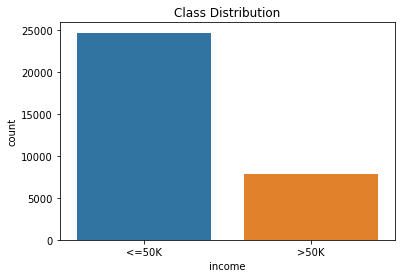

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='income', data=df)
plt.title("Class Distribution")
plt.show()

In [7]:
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')


In [8]:
df = df.dropna()   

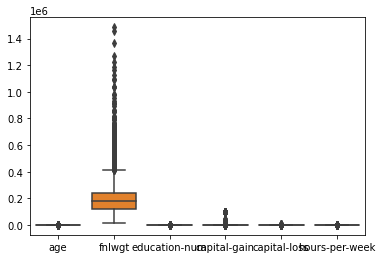

In [9]:
sns.boxplot(data=df)
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Correct target column
X = df.drop('income', axis=1)
y = df['income']

In [11]:
X = pd.get_dummies(X)

In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Features & Target
X = df.drop('income', axis=1)
y = df['income']

# Convert categorical → numeric
X = pd.get_dummies(X)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [15]:
y_pred = model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='>50K'))
print("Recall:", recall_score(y_test, y_pred, pos_label='>50K'))
print("F1 Score:", f1_score(y_test, y_pred, pos_label='>50K'))

Accuracy: 0.8569015814524796
Precision: 0.7482517482517482
Recall: 0.6129853596435392
F1 Score: 0.6738978306508048


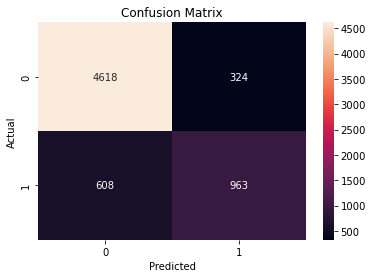

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()